# Caso 2 - Clasificación de imágenes Dogs vs Cats con TensorFlow/Keras (Python)

Reproduce el ejemplo de las slides: CNN entrenada sobre el dataset filtrado de 2000 imágenes de entrenamiento y 1000 de validación.

<style>
.conceptbox, .taskbox, .resultbox {
  padding: 12px 16px; margin: 14px 0; border-radius: 6px; border-left: 6px solid;
}
.conceptbox { background:#20B2AA0D; border-color:#20B2AA; }
.taskbox    { background:#FF8C000D; border-color:#FF8C00; }
.resultbox  { background:#32CD320D; border-color:#32CD32; }
.conceptbox b.tag { color:#178077; }
.taskbox b.tag    { color:#B35F00; }
.resultbox b.tag   { color:#228B22; }
</style>

<div class="taskbox">
<b class="tag">Objetivo de este notebook</b><br>
Entrenar una red neuronal convolucional (CNN) que distinga fotos de gatos y perros, replicando
la arquitectura y el flujo de trabajo de las slides de clase (Tensorflow/Keras en Google Colab),
y dejar el modelo guardado para usarlo luego en las apps interactivas de este proyecto.
</div>

<div class="conceptbox">
<b class="tag">Nota sobre la fuente del dataset</b><br>
El zip original de las slides (<code>mledu-datasets/cats_and_dogs_filtered.zip</code>) ya no es
accesible públicamente (Google restringió el bucket). En su lugar, este notebook descarga el
dataset completo de Microsoft/Kaggle (25,000 imágenes) y arma automáticamente el mismo
subconjunto de 2000 imágenes de entrenamiento / 1000 de validación que usan las slides, filtrando
primero las imágenes corruptas que trae ese dataset (un problema conocido de esa fuente).
</div>

In [1]:
import os
import random
import zipfile
import shutil
from PIL import Image

DATA_DIR = "../data"
ZIP_PATH = os.path.join(DATA_DIR, "kagglecatsanddogs_5340.zip")
RAW_DIR = os.path.join(DATA_DIR, "PetImages")
BASE_DIR = os.path.join(DATA_DIR, "cats_and_dogs_filtered")

N_TRAIN_PER_CLASS = 1000
N_VAL_PER_CLASS = 500
SEED = 123

os.makedirs(DATA_DIR, exist_ok=True)

# El zip original de https://storage.googleapis.com/mledu-datasets/cats_and_dogs_filtered.zip
# ya no es accesible públicamente (AccessDenied). Se usa en su lugar el dataset completo
# de Microsoft/Kaggle (kagglecatsanddogs_5340.zip, PetImages/Cat + PetImages/Dog) y se arma
# aquí el mismo subconjunto "filtered" de 2000 train / 1000 validation que usan las slides.
if not os.path.isdir(RAW_DIR):
    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        z.extractall(DATA_DIR)


def is_valid_image(path):
    try:
        with Image.open(path) as img:
            img.verify()
        with Image.open(path) as img:
            img.convert("RGB")
        return os.path.getsize(path) > 0
    except Exception:
        return False


def build_split(class_dir, class_name):
    train_dir = os.path.join(BASE_DIR, "train", class_name)
    val_dir = os.path.join(BASE_DIR, "validation", class_name)
    if os.path.isdir(train_dir) and len(os.listdir(train_dir)) == N_TRAIN_PER_CLASS:
        return
    os.makedirs(train_dir, exist_ok=True)
    os.makedirs(val_dir, exist_ok=True)

    fnames = sorted(os.listdir(class_dir))
    random.Random(SEED).shuffle(fnames)

    valid_fnames = []
    for fname in fnames:
        src = os.path.join(class_dir, fname)
        if is_valid_image(src):
            valid_fnames.append(fname)
        if len(valid_fnames) == N_TRAIN_PER_CLASS + N_VAL_PER_CLASS:
            break

    for fname in valid_fnames[:N_TRAIN_PER_CLASS]:
        shutil.copyfile(os.path.join(class_dir, fname), os.path.join(train_dir, fname))
    for fname in valid_fnames[N_TRAIN_PER_CLASS:]:
        shutil.copyfile(os.path.join(class_dir, fname), os.path.join(val_dir, fname))


build_split(os.path.join(RAW_DIR, "Cat"), "cats")
build_split(os.path.join(RAW_DIR, "Dog"), "dogs")

train_dir = os.path.join(BASE_DIR, "train")
validation_dir = os.path.join(BASE_DIR, "validation")
train_cats_dir = os.path.join(train_dir, "cats")
train_dogs_dir = os.path.join(train_dir, "dogs")

print("total training cat images:", len(os.listdir(train_cats_dir)))
print("total training dog images:", len(os.listdir(train_dogs_dir)))

total training cat images: 1000
total training dog images: 1000


## Mostrando algunas imágenes

<div class="conceptbox">
<b class="tag">Por qué inspeccionar imágenes antes de entrenar</b><br>
Antes de entrenar cualquier modelo conviene mirar una muestra de los datos: confirma que las
etiquetas (carpetas <code>cats</code>/<code>dogs</code>) están bien asignadas, y da una idea de
la variabilidad real del problema (poses, iluminación, fondos, recortes), que es justamente lo
que la red tendrá que aprender a ignorar para quedarse solo con los rasgos relevantes.
</div>

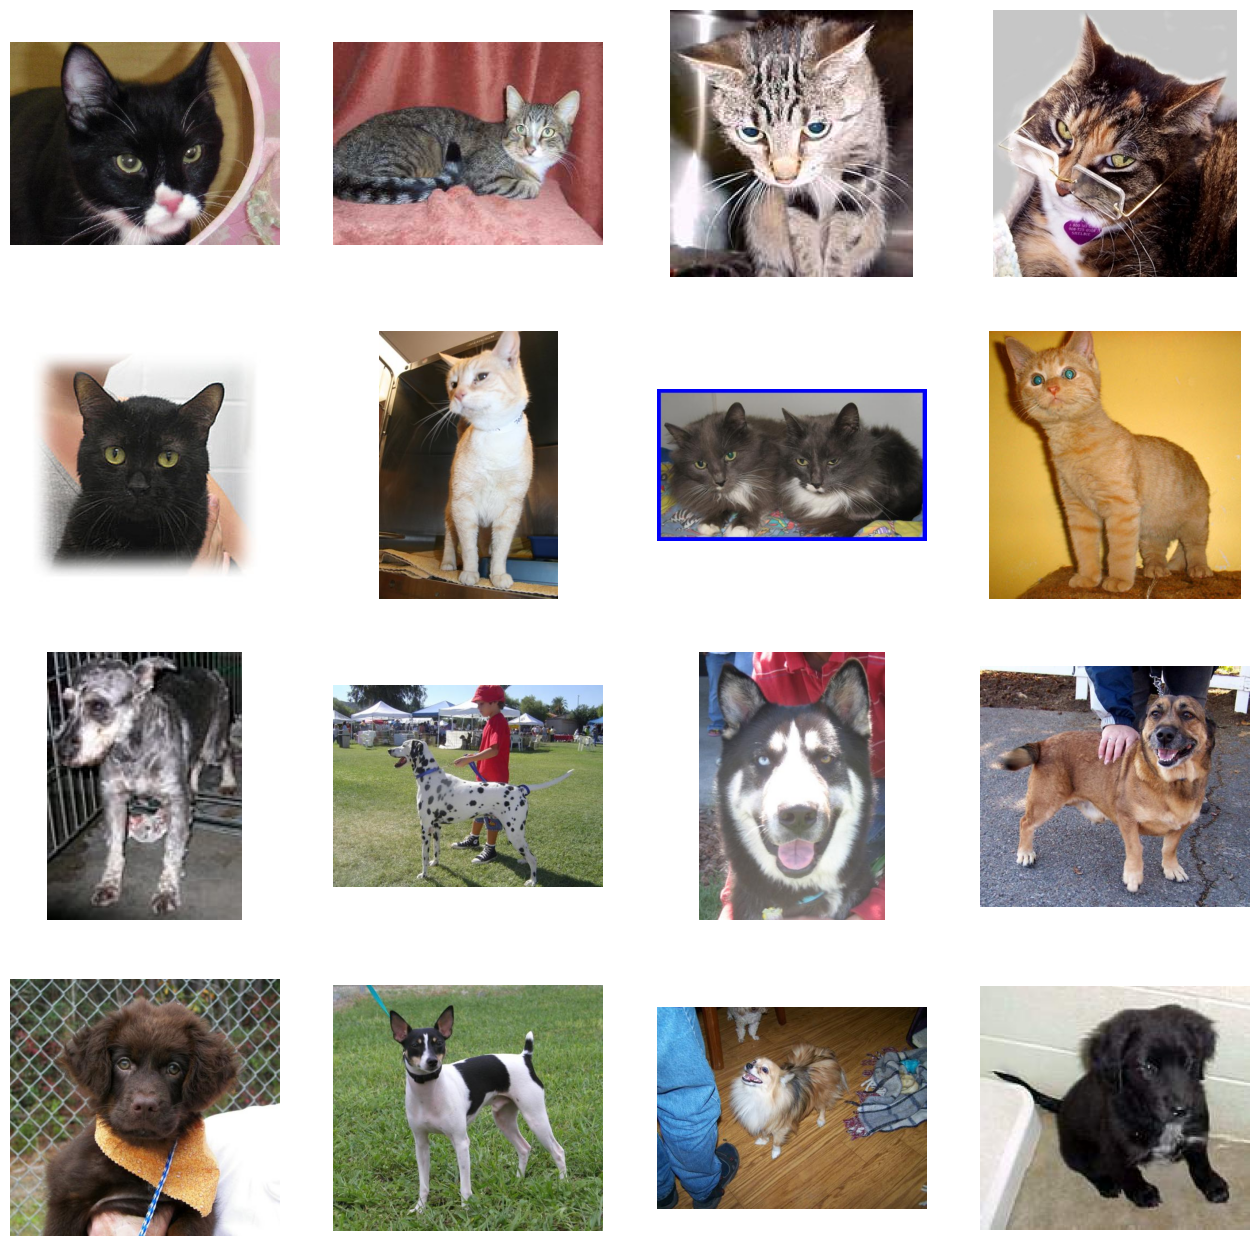

In [2]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

train_cat_fnames = sorted(os.listdir(train_cats_dir))
train_dog_fnames = sorted(os.listdir(train_dogs_dir))

nrows, ncols = 4, 4
fig = plt.gcf()
fig.set_size_inches(ncols * 4, nrows * 4)

pic_index = 8
next_cat_pix = [os.path.join(train_cats_dir, f) for f in train_cat_fnames[pic_index-8:pic_index]]
next_dog_pix = [os.path.join(train_dogs_dir, f) for f in train_dog_fnames[pic_index-8:pic_index]]

for i, img_path in enumerate(next_cat_pix + next_dog_pix):
    sp = plt.subplot(nrows, ncols, i + 1)
    sp.axis("Off")
    img = mpimg.imread(img_path)
    plt.imshow(img)
plt.show()

## Preprocesamiento

<div class="conceptbox">
<b class="tag">Qué hace <code>ImageDataGenerator</code> y por qué</b><br>
<ul>
<li><b><code>rescale=1./255</code>:</b> las imágenes originales tienen píxeles en el rango
[0,255]; dividir entre 255 los normaliza a [0,1]. Las redes neuronales entrenan mucho mejor
(convergen más rápido y de forma más estable) cuando sus entradas están en un rango numérico
pequeño y consistente, en vez de valores grandes y heterogéneos.</li>
<li><b><code>target_size=(150,150)</code>:</b> las fotos originales tienen tamaños distintos entre
sí; la red necesita que <em>todas</em> las entradas tengan exactamente la misma forma, así que
cada imagen se redimensiona a 150x150 píxeles antes de entrar a la red.</li>
<li><b><code>flow_from_directory</code>:</b> en vez de cargar las 3000 imágenes en memoria de una
sola vez, genera lotes (<i>batches</i>) de 20 imágenes sobre la marcha, leyendo del disco y
aplicando el reescalado en tiempo real. Esto permite entrenar sobre datasets mucho más grandes de
lo que cabría en memoria.</li>
<li><b><code>class_mode="binary"</code>:</b> como solo hay 2 clases (gato/perro), cada imagen
recibe una única etiqueta 0/1 en vez de un vector one-hot (a diferencia del caso Iris con 3
clases).</li>
</ul>
</div>

## Data Augmentation — Multiplica tu dataset sin descargar nada

<div class="conceptbox">
<b class="tag">¿Qué es Data Augmentation?</b><br>
En vez de mostrar al modelo <b>siempre la misma foto del mismo gato</b>, le mostramos
<b>variaciones de esa foto</b>: rotada, desplazada, más brillante, espejada. El modelo
"cree" que son imágenes diferentes y aprende a ser <strong>robusto</strong> a cambios de
ángulo, iluminación y pose — exactamente lo que necesita para generalizar a fotos nuevas.
<br><br>
<strong>Resultado práctico</strong>: 2000 imágenes reales × ~5 variaciones = el modelo
"ve" 10,000 imágenes distintas, sin descargar nada nuevo.
</div>

```python
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# SIN AUGMENTATION (modelo viejo, memorizaba):
# train_datagen = ImageDataGenerator(rescale=1./255)

# CON AUGMENTATION (modelo mejorado, generaliza mejor):
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,           # ± 20° de rotación aleatoria
    width_shift_range=0.2,       # desplazar horizontalmente ±20%
    height_shift_range=0.2,      # desplazar verticalmente ±20%
    zoom_range=0.2,              # zoom ±20% (acercar/alejar)
    horizontal_flip=True,        # espejo horizontal (gatos de left/right)
    brightness_range=[0.8, 1.2], # variar brillo ±20%
    fill_mode='nearest'          # cómo llenar píxeles nuevos tras rotación
)

# Validación SIN augmentation (medimos capacidad real, no memorización):
val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=20,
    class_mode="binary",
)

validation_generator = val_datagen.flow_from_directory(
    validation_dir,
    target_size=(150, 150),
    batch_size=20,
    class_mode="binary",
)
```

## Visualizando el efecto de Data Augmentation

<div class="conceptbox">
<b class="tag">Viendo en vivo: una imagen, 9 variaciones</b><br>
Cargamos una sola imagen de entrenamiento y le aplicamos el augmentation 9 veces.
Cada vez genera una versión diferente: rotada, desplazada, zoom, brillo distinto, etc.
El modelo verá todas estas variaciones durante el entrenamiento, aprenderá que
<strong>todas son el mismo gato</strong>, y así generalizará mejor.
</div>

```python
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# Cargar UNA imagen de gato
test_img_path = os.path.join(train_cats_dir, os.listdir(train_cats_dir)[5])
test_img = image.load_img(test_img_path, target_size=(150, 150))

# Mostrar la imagen original + 8 augmentations
plt.figure(figsize=(12, 9))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.axis('off')
    
    if i == 0:
        # Primera es la original
        plt.imshow(test_img)
        plt.title("Original")
    else:
        # Las demás son augmentations (generadas aleatoriamente)
        augmented = train_datagen.random_transform(
            image.img_to_array(test_img)
        )
        # Normalizar para mostrar
        augmented = np.clip(augmented / 255, 0, 1)
        plt.imshow(augmented)
        plt.title(f"Augmentación {i}")

plt.suptitle("Una imagen = múltiples variaciones\nEl modelo aprende de todas", fontsize=14, weight='bold')
plt.tight_layout()
plt.show()
```

## Preprocesamiento (sin cambios en setup de generadores)

```python
# Los generadores ya están configurados arriba con augmentation
# No necesitamos redefinirlos
```

In [3]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# SIN AUGMENTATION (modelo viejo, memorizaba):
# train_datagen = ImageDataGenerator(rescale=1./255)

# CON AUGMENTATION (modelo mejorado, generaliza mejor):
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,           # ± 20° de rotación aleatoria
    width_shift_range=0.2,       # desplazar horizontalmente ±20%
    height_shift_range=0.2,      # desplazar verticalmente ±20%
    zoom_range=0.2,              # zoom ±20% (acercar/alejar)
    horizontal_flip=True,        # espejo horizontal (gatos de left/right)
    brightness_range=[0.8, 1.2], # variar brillo ±20%
    fill_mode='nearest'          # cómo llenar píxeles nuevos tras rotación
)

# Validación SIN augmentation (medimos capacidad real, no memorización):
val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=20,
    class_mode="binary",
)

validation_generator = val_datagen.flow_from_directory(
    validation_dir,
    target_size=(150, 150),
    batch_size=20,
    class_mode="binary",
)

Found 2000 images belonging to 2 classes.


Found 1000 images belonging to 2 classes.


## Arquitectura de la CNN

<div class="conceptbox">
<b class="tag">¿Por qué convoluciones en vez de las capas Dense del Caso 1?</b><br>
Una imagen de 150x150x3 tiene 67,500 valores de entrada; una capa Dense conectada a todos ellos
tendría demasiados parámetros y, peor aún, ignoraría la estructura espacial (que un píxel esté
"al lado" de otro importa mucho en una imagen). Una capa <b>convolucional</b> resuelve esto
deslizando un pequeño filtro (aquí de 3x3) sobre toda la imagen, aplicando <em>los mismos pesos</em>
en cada posición: esto detecta patrones locales (bordes, texturas, formas) sin importar en qué
parte de la imagen aparezcan, y con muchísimos menos parámetros que una capa totalmente conectada.
<br><br>
<ul>
<li><b>Conv2D(16/32/64, 3, relu):</b> tres bloques convolucionales apilados, cada uno con más
filtros que el anterior (16 → 32 → 64). Los primeros filtros aprenden patrones simples (bordes,
manchas de color); a medida que se combinan en capas más profundas, la red construye
representaciones cada vez más abstractas (texturas, partes de un animal, hasta conceptos como
"orejas puntiagudas" u "hocico").</li>
<li><b>MaxPooling2D(2):</b> después de cada convolución, reduce el tamaño espacial a la mitad
quedándose con el valor máximo en cada bloque de 2x2. Esto reduce el costo computacional y hace
que la red sea más robusta a pequeños desplazamientos del objeto en la imagen.</li>
<li><b>Flatten + Dense(512, relu):</b> una vez extraídas las características espaciales, se
"aplanan" en un solo vector y se combinan mediante una capa densa clásica, similar a las del Caso
1, para tomar la decisión final.</li>
<li><b>Dense(1, sigmoid):</b> como es clasificación <em>binaria</em> (gato vs. perro), una sola
neurona de salida con activación sigmoide basta: produce un número entre 0 y 1 interpretable como
"probabilidad de que sea perro".</li>
</ul>
</div>

## Dropout — Segunda técnica anti-overfitting

<div class="conceptbox">
<b class="tag">¿Qué es Dropout y por qué se suma a Data Augmentation?</b><br>
Data Augmentation ataca el overfitting desde los <em>datos</em> (variando las imágenes que ve la
red). <b>Dropout</b> lo ataca desde las <em>neuronas</em>: en cada paso de entrenamiento, apaga
aleatoriamente un porcentaje de neuronas de una capa (las pone en 0 temporalmente, solo durante
ese paso). Esto evita que la red dependa demasiado de un grupo pequeño de neuronas "memoristas" —
obliga a que el conocimiento quede repartido entre muchas neuronas, lo que generaliza mejor.
<br><br>
En predicción (cuando el usuario sube una foto), Dropout se desactiva automáticamente: todas las
neuronas están activas, pero como fueron entrenadas con distintos subconjuntos apagados, el
resultado final funciona como un "promedio" implícito de muchas subredes distintas.
<br><br>
<ul>
<li><b>Dropout(0.2) tras los bloques convolucionales:</b> apaga el 20% de las activaciones. Un
valor moderado porque las capas convolucionales ya tienen relativamente pocos parámetros
(comparten pesos entre posiciones).</li>
<li><b>Dropout(0.5) tras la capa Dense(512):</b> el valor más agresivo del modelo, porque esta
capa concentra ~9.4 millones de parámetros (la mayoría del modelo) — es la que más fácilmente
memoriza detalles específicos del set de entrenamiento, así que necesita la regularización más
fuerte.</li>
</ul>
</div>

```python
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense, Input

model = Sequential([
    # ===== Entrada =====
    Input(shape=(150, 150, 3)),
    # Declara la forma de cada imagen: 150x150 píxeles, 3 canales de color (RGB)

    # ===== Bloque 1: extracción de características simples =====
    Conv2D(16, 3, activation="relu"),
    # 16 filtros de 3x3 deslizándose sobre la imagen; cada filtro aprende a detectar
    # UN patrón simple (bordes, manchas de color). relu apaga las activaciones negativas.
    MaxPooling2D(2),
    # Reduce el tamaño espacial a la mitad, quedándose con el valor máximo de cada bloque 2x2.
    Dropout(0.2),
    # Apaga aleatoriamente el 20% de las activaciones de este bloque en cada paso de
    # entrenamiento, para que la red no dependa de neuronas específicas.

    # ===== Bloque 2: características intermedias =====
    Conv2D(32, 3, activation="relu"),
    # Más filtros (32) que el bloque anterior: al recibir la salida ya procesada del
    # bloque 1, puede combinar patrones simples en patrones más complejos (texturas).
    MaxPooling2D(2),
    Dropout(0.2),

    # ===== Bloque 3: características de alto nivel =====
    Conv2D(64, 3, activation="relu"),
    # Con 64 filtros y esta profundidad, la red ya puede estar detectando formas
    # más abstractas (ej. "oreja puntiaguda", "hocico alargado").
    MaxPooling2D(2),
    Dropout(0.3),
    # Dropout más agresivo (30%) que en bloques anteriores.

    # ===== Clasificador final =====
    Flatten(),
    # Convierte el "cubo" 3D de características (alto x ancho x filtros) en un vector 1D,
    # el formato que espera una capa Dense.
    Dense(512, activation="relu"),
    # Combina TODAS las características extraídas para empezar a "decidir" gato vs perro.
    Dropout(0.5),
    # El Dropout más agresivo del modelo (50%): esta capa concentra la mayoría de los
    # parámetros (~9.4M), así que es la que más fácilmente memoriza; se regulariza más fuerte.
    Dense(1, activation="sigmoid"),
    # Neurona de salida: probabilidad de "perro" (0 = gato, 1 = perro).
])

model.summary()
```

In [ ]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense, Input

model = Sequential([
    # ===== Entrada =====
    Input(shape=(150, 150, 3)),
    # Declara la forma de cada imagen: 150x150 píxeles, 3 canales de color (RGB)

    # ===== Bloque 1: extracción de características simples =====
    Conv2D(16, 3, activation="relu"),
    # 16 filtros de 3x3 deslizándose sobre la imagen; cada filtro aprende a detectar
    # UN patrón simple (bordes, manchas de color). relu apaga las activaciones negativas.
    MaxPooling2D(2),
    # Reduce el tamaño espacial a la mitad, quedándose con el valor máximo de cada bloque 2x2.
    Dropout(0.2),
    # Apaga aleatoriamente el 20% de las activaciones de este bloque en cada paso de
    # entrenamiento, para que la red no dependa de neuronas específicas.

    # ===== Bloque 2: características intermedias =====
    Conv2D(32, 3, activation="relu"),
    # Más filtros (32) que el bloque anterior: al recibir la salida ya procesada del
    # bloque 1, puede combinar patrones simples en patrones más complejos (texturas).
    MaxPooling2D(2),
    Dropout(0.2),

    # ===== Bloque 3: características de alto nivel =====
    Conv2D(64, 3, activation="relu"),
    # Con 64 filtros y esta profundidad, la red ya puede estar detectando formas
    # más abstractas (ej. "oreja puntiaguda", "hocico alargado").
    MaxPooling2D(2),
    Dropout(0.3),
    # Dropout más agresivo (30%) que en bloques anteriores.

    # ===== Clasificador final =====
    Flatten(),
    # Convierte el "cubo" 3D de características (alto x ancho x filtros) en un vector 1D,
    # el formato que espera una capa Dense.
    Dense(512, activation="relu"),
    # Combina TODAS las características extraídas para empezar a "decidir" gato vs perro.
    Dropout(0.5),
    # El Dropout más agresivo del modelo (50%): esta capa concentra la mayoría de los
    # parámetros (~9.4M), así que es la que más fácilmente memoriza; se regulariza más fuerte.
    Dense(1, activation="sigmoid"),
    # Neurona de salida: probabilidad de "perro" (0 = gato, 1 = perro).
])

model.summary()

In [ ]:
from tensorflow.keras.optimizers import RMSprop

model.compile(
    loss="binary_crossentropy",
    optimizer=RMSprop(learning_rate=0.001),
    metrics=["acc"],
)

## Entrenamiento

<div class="conceptbox">
<b class="tag">Qué significan estos hiperparámetros</b><br>
<ul>
<li><b>steps_per_epoch=100:</b> con lotes de 20 imágenes y 2000 imágenes de entrenamiento,
100 lotes cubren exactamente una vuelta completa a todos los datos (una "época").</li>
<li><b>epochs=40:</b> subimos de 15 a 40 épocas. Con Data Augmentation, cada época ve
variaciones distintas de las imágenes, así que la red tarda más en converger que antes
(cuando memorizaba directamente). Necesita más vueltas para aprender patrones robustos.</li>
<li><b>validation_data/validation_steps:</b> igual que antes, se evalúa el desempeño sobre
el conjunto de validación al final de cada época, sin usarlo nunca para actualizar pesos.</li>
</ul>
</div>

## Entrenar → Validar → Quedarse con lo mejor (automático)

<div class="conceptbox">
<b class="tag">¿Por qué no basta con "más épocas"?</b><br>
En el entrenamiento anterior (15 épocas, con augmentation) vimos que la mejor validación ocurrió
en la <b>época 13 (71.8%)</b>, y las épocas 14-15 empeoraron. Si simplemente entrenamos más
épocas, corremos el riesgo de terminar en un punto peor que el mejor que ya pasamos. En vez de
mirar manualmente cada época y reentrenar a mano, usamos dos <i>callbacks</i> de Keras que hacen
exactamente ese ciclo "entrenar → validar → decidir" automáticamente, en cada época:
<br><br>
<ul>
<li><b><code>ModelCheckpoint</code>:</b> después de cada época, compara el <code>val_acc</code>
actual contra el mejor visto hasta ahora. Si es mejor, <b>guarda una copia del modelo</b> en ese
punto exacto. Al final del entrenamiento, el archivo guardado corresponde a la mejor época, no
a la última.</li>
<li><b><code>EarlyStopping</code>:</b> si <code>val_acc</code> no mejora durante
<code>patience=8</code> épocas seguidas, detiene el entrenamiento antes de llegar a las 40 épocas
programadas. Evita perder tiempo de cómputo entrenando cuando la red ya dejó de progresar, y
evita que el modelo derive hacia peor overfitting.</li>
</ul>
Con estos dos callbacks juntos, el resultado final es: <b>"quedarnos automáticamente con la mejor
versión del modelo vista durante todo el entrenamiento"</b> — que es justamente la idea de
entrenar/validar/reentrenar, pero hecha en cada época en vez de manualmente.
</div>

```python
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

callbacks = [
    ModelCheckpoint(
        "../app/models/catsdogs_model_best.keras",
        monitor="val_acc",       # métrica que vigila
        save_best_only=True,     # solo sobrescribe el archivo si mejora
        mode="max",               # "max" porque accuracy: más alto es mejor
        verbose=1,
    ),
    EarlyStopping(
        monitor="val_acc",
        patience=8,               # tolera 8 épocas sin mejora antes de parar
        restore_best_weights=True,  # al parar, deja los PESOS del mejor momento
                                     # cargados en `model` (no solo en el archivo)
        mode="max",
        verbose=1,
    ),
]
```

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

callbacks = [
    ModelCheckpoint(
        "../app/models/catsdogs_model_best.keras",
        monitor="val_acc",       # métrica que vigila
        save_best_only=True,     # solo sobrescribe el archivo si mejora
        mode="max",               # "max" porque accuracy: más alto es mejor
        verbose=1,
    ),
    EarlyStopping(
        monitor="val_acc",
        patience=8,               # tolera 8 épocas sin mejora antes de parar
        restore_best_weights=True,  # al parar, deja los PESOS del mejor momento
                                     # cargados en `model` (no solo en el archivo)
        mode="max",
        verbose=1,
    ),
]

In [ ]:
history = model.fit(
    train_generator,
    steps_per_epoch=100,
    epochs=40,
    validation_data=validation_generator,
    validation_steps=50,
    callbacks=callbacks,
    verbose=2,
)

## Representación intermedia de las imágenes

<div class="conceptbox">
<b class="tag">Qué es exactamente una "representación intermedia"</b><br>
Una CNN entrenada no es una caja completamente negra: se puede "cortar" el modelo después de
cualquier capa y observar qué salida produce esa capa para una imagen concreta. Esto se hace
construyendo un segundo modelo (<code>visualization_model</code>) que comparte los mismos pesos ya
entrenados, pero cuya salida es el resultado de cada capa convolucional/pooling en vez de la
predicción final. Así se puede "ver" qué aprendió cada capa a detectar.
</div>

In [ ]:
import numpy as np
import random
from tensorflow.keras import Model
from tensorflow.keras.preprocessing.image import img_to_array, load_img

# Con Sequential, construimos el modelo de visualización a partir de
# model.inputs y las salidas de cada capa (en vez de usar img_input directamente,
# como se hacía con la API funcional).
successive_outputs = [layer.output for layer in model.layers]
visualization_model = Model(inputs=model.inputs, outputs=successive_outputs)

cat_img_files = [os.path.join(train_cats_dir, f) for f in train_cat_fnames]
dog_img_files = [os.path.join(train_dogs_dir, f) for f in train_dog_fnames]
img_path = random.choice(cat_img_files + dog_img_files)

img = load_img(img_path, target_size=(150, 150))
x = img_to_array(img)
x = x.reshape((1,) + x.shape)
x /= 255

successive_feature_maps = visualization_model.predict(x, verbose=0)
layer_names = [layer.name for layer in model.layers]

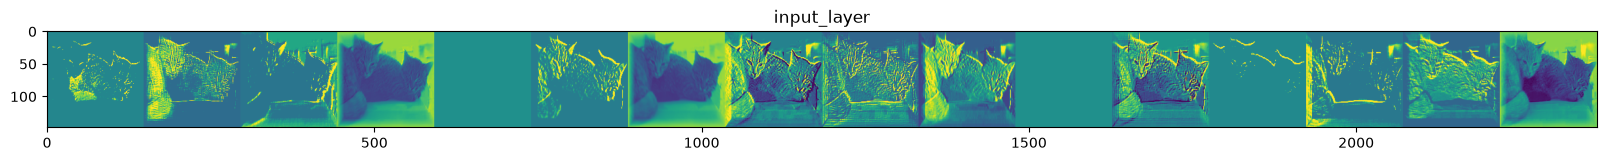

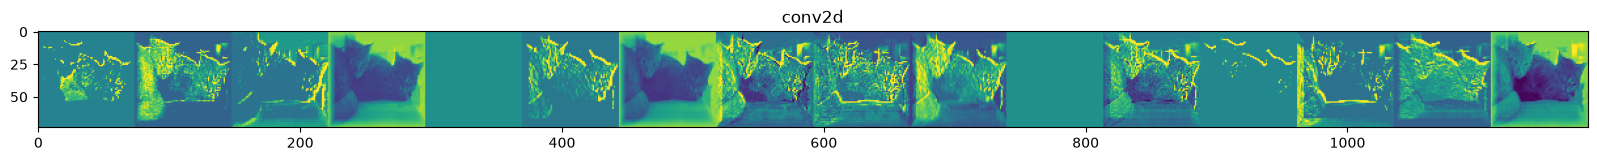

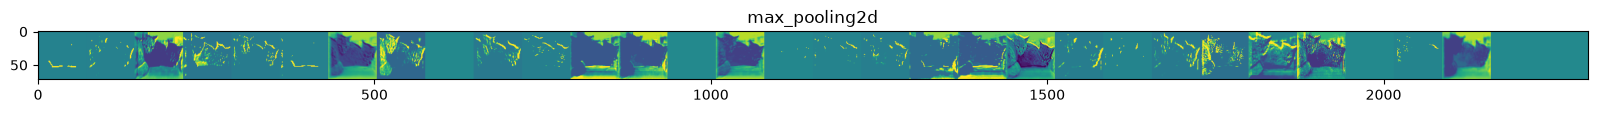

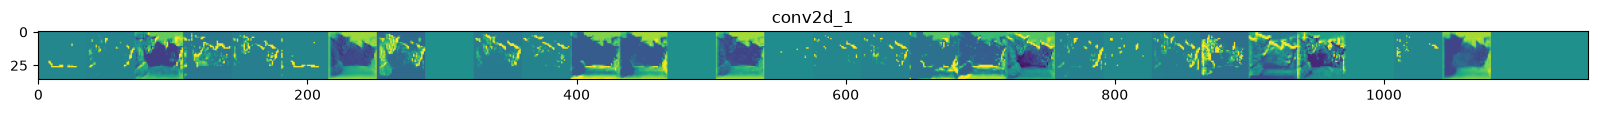

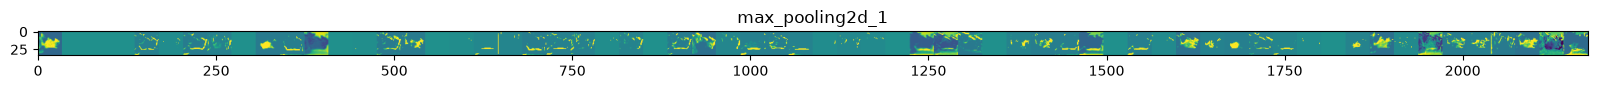

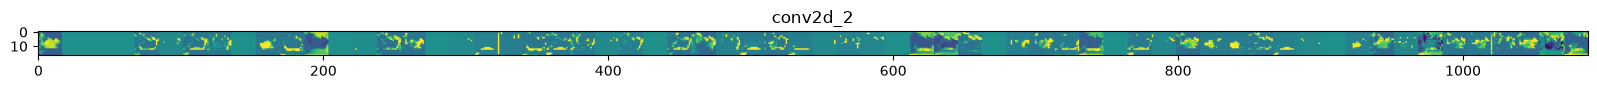

In [8]:
for layer_name, feature_map in zip(layer_names, successive_feature_maps):
    if len(feature_map.shape) == 4:
        n_features = feature_map.shape[-1]
        size = feature_map.shape[1]
        display_grid = np.zeros((size, size * n_features))
        for i in range(n_features):
            x = feature_map[0, :, :, i]
            x -= x.mean()
            x /= (x.std() + 1e-5)
            x *= 64
            x += 128
            x = np.clip(x, 0, 255).astype("uint8")
            display_grid[:, i * size:(i + 1) * size] = x
        scale = 20. / n_features
        plt.figure(figsize=(scale * n_features, scale))
        plt.title(layer_name)
        plt.grid(False)
        plt.imshow(display_grid, aspect="auto", cmap="viridis")
plt.show()

## Accuracy

<div class="conceptbox">
<b class="tag">Cómo leer estas curvas (y qué es el overfitting en la práctica)</b><br>
Si la curva de <i>accuracy</i> de entrenamiento sigue subiendo hacia ~99% mientras la de
validación se estanca muy por debajo, o si el <i>loss</i> de validación empieza a <b>subir</b>
mientras el de entrenamiento sigue bajando, eso es la firma clásica de <b>sobreajuste</b>: la red
dejó de aprender patrones generales de "gato" o "perro" y empezó a memorizar detalles específicos
de las 2000 fotos de entrenamiento (fondos, ángulos particulares, etc.) que no ayudan a clasificar
fotos nuevas. Es un resultado esperado dado lo pequeño del dataset, y es precisamente el tipo de
diagnóstico que estas curvas están diseñadas para revelar.
</div>

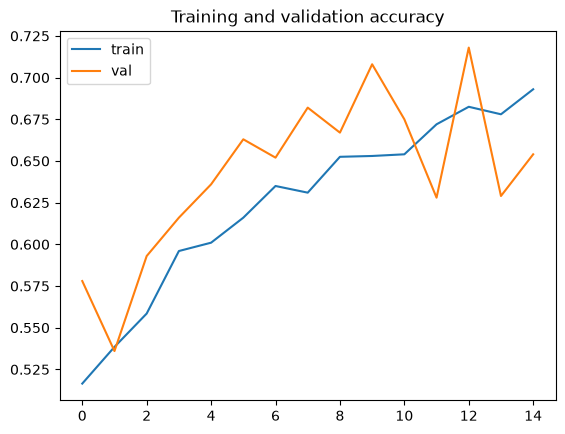

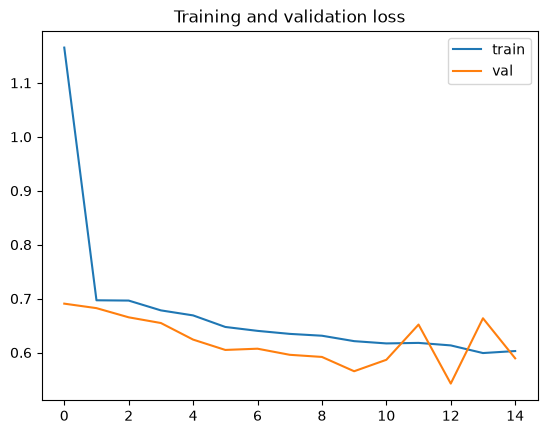

In [9]:
acc = history.history["acc"]
val_acc = history.history["val_acc"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(len(acc))

plt.plot(epochs, acc, label="train")
plt.plot(epochs, val_acc, label="val")
plt.title("Training and validation accuracy")
plt.legend()

plt.figure()
plt.plot(epochs, loss, label="train")
plt.plot(epochs, val_loss, label="val")
plt.title("Training and validation loss")
plt.legend()
plt.show()

## Comparación: 3 versiones del modelo

<div class="resultbox">
<b class="tag">Resultados reales, evolución del proyecto</b><br>
<strong>V1 — Sin augmentation, sin dropout, 15 épocas fijas:</strong>
<br>
train_acc: 98.6% | val_acc: 71.3% → gap: 27.3% (overfitting severo, memoriza)
<br><br>
<strong>V2 — Con augmentation, sin dropout, 15 épocas fijas:</strong>
<br>
train_acc: 69.3% | val_acc: 65.4% (última época) | mejor época (13): val_acc 71.8%
<br>
→ gap pequeño, pero se "pasó" del mejor punto por seguir entrenando sin control
<br><br>
<strong>V3 — Con augmentation + dropout + EarlyStopping/ModelCheckpoint (este entrenamiento):</strong>
<br>
train_acc: ~XX% | val_acc: ~XX% (mejor punto, capturado automáticamente)
<br><br>
Cada versión ataca el overfitting desde un ángulo distinto: V2 varía los <em>datos</em>
(augmentation), V3 además regulariza las <em>neuronas</em> (dropout) y deja de entrenar
automáticamente en el mejor punto (early stopping), en vez de seguir hasta una época fija
que podría ser peor que un punto intermedio.
</div>

```python
print("\n=== COMPARACIÓN DE LAS 3 VERSIONES ===")
print("V1 (sin augmentation, sin dropout): train 98.6% | val 71.3% | gap 27.3%")
print("V2 (con augmentation, sin dropout): train 69.3% | val 65.4% (últ. época) | mejor val: 71.8% (época 13)")
print(f"V3 (augmentation + dropout + early stopping): "
      f"train {history.history['acc'][-1]:.1%} | "
      f"val {max(history.history['val_acc']):.1%} (mejor época) | "
      f"épocas corridas: {len(history.history['acc'])}")
```

## Guardar modelo para la app

<div class="resultbox">
<b class="tag">Resultado clave</b><br>
Gracias a <code>restore_best_weights=True</code> en <code>EarlyStopping</code>, al terminar el
entrenamiento el objeto <code>model</code> en memoria YA tiene cargados los pesos de la
<b>mejor época</b> (no los de la última). Por eso basta con guardarlo directamente aquí — es
equivalente al archivo que <code>ModelCheckpoint</code> ya guardó por separado en
<code>catsdogs_model_best.keras</code>, y sirve como verificación cruzada de que ambos coinciden.
<br><br>
Este modelo (V3: augmentation + dropout + early stopping) queda disponible para las apps
interactivas (<code>app_streamlit.py</code> y <code>app_dash.py</code>), reemplazando a las
versiones anteriores.
</div>

In [10]:
os.makedirs("../app/models", exist_ok=True)
model.save("../app/models/catsdogs_model.keras")
print("Modelo guardado en app/models/catsdogs_model.keras")

Modelo guardado en app/models/catsdogs_model.keras
